In [2]:
#Mount the Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [7]:

#unpack the Zip file
import shutil
shutil.unpack_archive('/content/drive/MyDrive/Colab Notebooks/Datasets/Capstone1_Part1/Images.zip')
print("UnZipped")

UnZipped


In [8]:
#Images are extracted in the Content Images Folder
images_dir='content/Images'


In [9]:
import pandas as pd
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

print("Imported Libraries")

Imported Libraries


In [19]:
# Load the labels from labels.csv
labels_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/Capstone1_Part1/labels.csv', sep=',', header=None)
labels_df.columns = ['image_id', 'class', 'x_min', 'y_min', 'x_max', 'y_max']
print("Imported the Labels Dataset")

Imported the Labels Dataset


In [15]:
labels_df

,image_id,class,x_min,y_min,x_max,y_max
0,0,pickup_truck,213,34,255,50
1,0,car,194,78,273,122
2,0,car,155,27,183,35
3,0,articulated_truck,43,25,109,55
4,0,car,106,32,124,45
...,...,...,...,...,...,...
351544,110590,car,18,57,97,98
351545,110591,articulated_truck,2,71,690,351
351546,110592,pickup_truck,3,240,214,378
351547,110592,car,465,111,507,135


#we cannot proceed with large dataset since the GPU / Compute limitations in the Google Colab, so create a demo model with less number of the images. so implement the model with small number of images

In [20]:
#Do zero padding for the image id to match the image name in the google drive and we are taking only 1000 images

labels_df['image_id'] = labels_df['image_id'].apply(lambda x: f"{x:08d}")
labels_df

,image_id,class,x_min,y_min,x_max,y_max
0,00000000,pickup_truck,213,34,255,50
1,00000000,car,194,78,273,122
2,00000000,car,155,27,183,35
3,00000000,articulated_truck,43,25,109,55
4,00000000,car,106,32,124,45
...,...,...,...,...,...,...
351544,00110590,car,18,57,97,98
351545,00110591,articulated_truck,2,71,690,351
351546,00110592,pickup_truck,3,240,214,378
351547,00110592,car,465,111,507,135


In [21]:
# Use iloc to pick the first 1000 labels
labels_df = labels_df.iloc[:1000]
labels_df

,image_id,class,x_min,y_min,x_max,y_max
0,00000000,pickup_truck,213,34,255,50
1,00000000,car,194,78,273,122
2,00000000,car,155,27,183,35
3,00000000,articulated_truck,43,25,109,55
4,00000000,car,106,32,124,45
...,...,...,...,...,...,...
995,00000306,motorized_vehicle,36,44,55,56
996,00000306,car,110,93,208,140
997,00000306,articulated_truck,55,19,111,37
998,00000307,car,2,233,17,283


#image data pre processing, reshaping, resizing

In [22]:
images_dir = 'Images/'
images = []
target_size = (224, 224)  # Adjust this size according to your model's requirements.
for index, row in labels_df.iterrows():
    img_path = os.path.join(images_dir, f"{row['image_id']}.jpg")
    img = cv2.imread(img_path)
    if img is not None:
        if len(img.shape) == 2:  # If grayscale, convert to RGB
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = cv2.resize(img, target_size)  # Resize image
        images.append(img)
    else:
        print(f"Error loading image: {img_path}")
images = np.array(images)  # Convert list of images to a NumPy array
if len(images) == 0:
    print("No images loaded. Please check the image paths.")
else:
    print(f"{len(images)} images loaded successfully.")

1000 images loaded successfully.


In [26]:
print("Total Images :",len(images)) #1000
print("Image Size : ", images[0].shape) #224*224

Total Images : 1000
Image Size :  (224, 224, 3)


In [27]:
# Analyze the distribution of vehicle types in the limited dataset
vehicle_types = labels_df['class'].value_counts()
print("Distribution of vehicle types:")
print(vehicle_types)

Distribution of vehicle types:
class
car                      682
pickup_truck             111
motorized_vehicle         61
articulated_truck         30
work_van                  29
bus                       28
pedestrian                23
single_unit_truck         18
bicycle                   12
non-motorized_vehicle      5
motorcycle                 1
Name: count, dtype: int64


In [29]:
# Address data quality issues arising from the discrepancy between labels and actual image filenames
# Sorting the image filenames
labels_df = labels_df.sort_values('image_id')
print("Sorted")

Sorted


In [30]:
#Image Quality Check and resize to 224*224

if len(images) > 0:
    processed_images = [cv2.resize(img, (224, 224)) for img in images]  # Adjust dimensions as needed
    processed_images = np.array(processed_images)
    print("Images resized successfully.")

Images resized successfully.


In [32]:
#Data Preprocessing for Labels
labels = labels_df['class'].to_numpy()
bounding_boxes = labels_df[['x_min', 'y_min', 'x_max', 'y_max']].to_numpy()

In [35]:
#Convert labesl to one-hot encoding, labels are converted into integer numbers, because models needs integer values
unique_labels = np.unique(labels)
label_to_index = {label: index for index, label in enumerate(unique_labels)}
index_to_label = {index: label for index, label in enumerate(unique_labels)}
labels = np.array([label_to_index[label] for label in labels])
labels

array([ 8,  3,  3,  0,  3,  2,  2,  3,  3,  3,  3,  5,  3,  3,  2,  3,  0,
        3,  3,  8,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        8,  3,  3,  3,  3,  3,  3,  3,  3,  3,  2,  3,  3,  8,  3,  0, 10,
        5,  3,  5,  3,  3,  3,  3,  3,  0,  3,  3,  3,  2,  2,  3,  5,  3,
        3,  3,  3,  5,  8,  3,  8,  3,  3,  8,  3,  3,  3,  3,  9,  9,  3,
        8,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  0,  3,  3,  3,  8,  3,
        3,  9,  3,  3,  8,  3,  8,  3,  3,  8,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3, 10,  2,  3,  3,  3,  5, 10,  3,  3,  3,  3,  3,  3,
        8,  3,  3,  3,  3,  3,  3,  3,  5,  7,  3,  3,  5,  3,  3,  3,  8,
        3,  3,  8,  3,  3,  3,  5,  3,  8,  8, 10,  8,  8,  3,  8,  3,  3,
        3,  5,  3,  5,  3,  5,  8,  8,  8,  3,  3, 10,  0,  5,  3,  8,  3,
        3,  3,  8,  8,  5,  3,  3,  3,  3,  3,  8,  8,  3,  8, 10,  3,  3,
        8,  3,  8,  3,  3,  3,  3,  3,  3,  3,  3,  3,  5,  0,  3,  3,  3,
        3,  3,  1,  3,  3

#Model Building

In [36]:
#Train the Images with 80% vs 20% with 80% as training data
X_train, X_test, y_train, y_test, bbox_train, bbox_test = train_test_split(processed_images, labels, bounding_boxes, test_size=0.2, random_state=42)

In [38]:
print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)
print("bbox_train shape:", bbox_train.shape)
print("First few y_train labels:", y_train[:5])
print("First few bbox_train labels:", bbox_train[:5])

X_train Shape: (800, 224, 224, 3)
y_train Shape: (800,)
bbox_train shape: (800, 4)
First few y_train labels: [3 3 3 8 3]
First few bbox_train labels: [[476 148 610 206]
 [573 219 675 285]
 [295 121 345 142]
 [324 110 381 128]
 [380 192 462 221]]


#Create an CNN Architecture for Object Detection

In [39]:
#we have 2 output layers
def create_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    vehicle_class = layers.Dense(num_classes, activation='softmax', name='vehicle_class')(x)
    bounding_box = layers.Dense(4, name='bounding_box')(x)
    model = keras.Model(inputs=inputs, outputs=[vehicle_class, bounding_box])
    return model

In [40]:
#Call the Model

input_shape = processed_images[0].shape
num_classes = len(unique_labels)
model = create_model(input_shape, num_classes)

In [41]:
#Compile the Model.

model.compile(optimizer='adam',
              loss={'vehicle_class': 'sparse_categorical_crossentropy', 'bounding_box': 'mse'},
              metrics={'vehicle_class': 'accuracy', 'bounding_box': 'mae'})

In [42]:
#Run the Model
model.fit(X_train, {'vehicle_class': y_train, 'bounding_box': bbox_train}, epochs=50, validation_data=(X_test, {'vehicle_class': y_test, 'bounding_box': bbox_test}))

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 158ms/step - bounding_box_loss: 329841.4688 - bounding_box_mae: 273.9555 - loss: 330361.7500 - vehicle_class_accuracy: 0.0213 - vehicle_class_loss: 520.1954 - val_bounding_box_loss: 29659.0957 - val_bounding_box_mae: 132.6151 - val_loss: 29520.0117 - val_vehicle_class_accuracy: 0.0200 - val_vehicle_class_loss: 743.1673
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - bounding_box_loss: 24485.3047 - bounding_box_mae: 123.8987 - loss: 25115.7676 - vehicle_class_accuracy: 0.0137 - vehicle_class_loss: 630.4638 - val_bounding_box_loss: 22822.9746 - val_bounding_box_mae: 118.7476 - val_loss: 22955.8066 - val_vehicle_class_accuracy: 0.0000e+00 - val_vehicle_class_loss: 488.5596
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - bounding_box_loss: 20540.7969 - bounding_box_mae: 110.9438 - loss: 20836.0547 - vehicle_class_accuracy: 0.0125 - vehicle_class_loss: 295.2561 - val_bounding_box_loss: 23296.0586 - val_bounding_box_mae: 113.7132 - val_loss

In [43]:
#Evaulate the model. Error will be higher, the reason the poor model architecture and less number of images
test_results = model.evaluate(X_test, {'vehicle_class': y_test, 'bounding_box': bbox_test}, verbose=2)
print('\nTest results:', test_results)

7/7 - 0s - 45ms/step - bounding_box_loss: 25182.0176 - bounding_box_mae: 114.6976 - loss: 24093.3809 - vehicle_class_accuracy: 0.6050 - vehicle_class_loss: 10.4570

Test results: [24093.380859375, 10.456997871398926, 25182.017578125, 114.69761657714844, 0.6050000190734863]


#Test the model by passing actual images


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


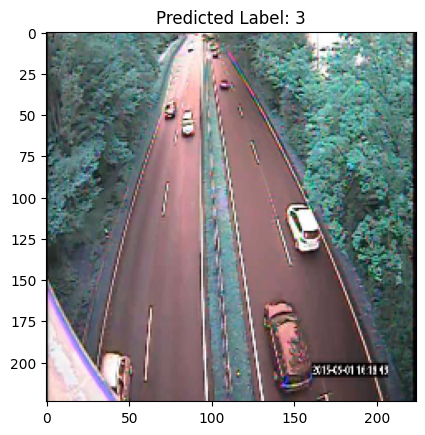

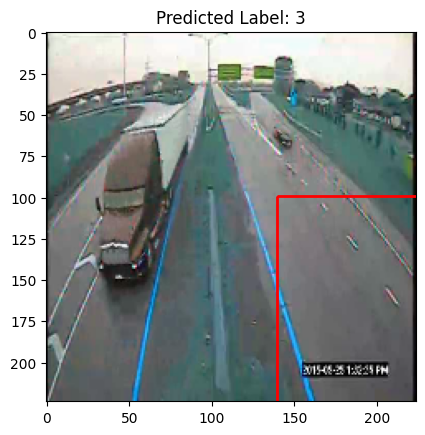

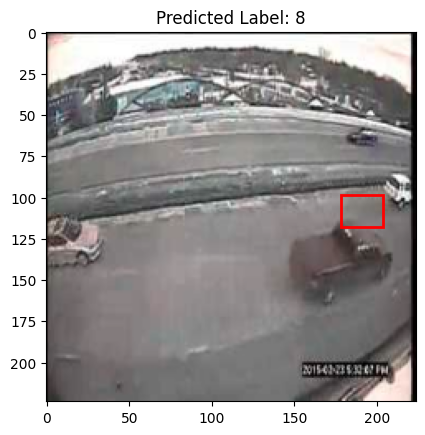

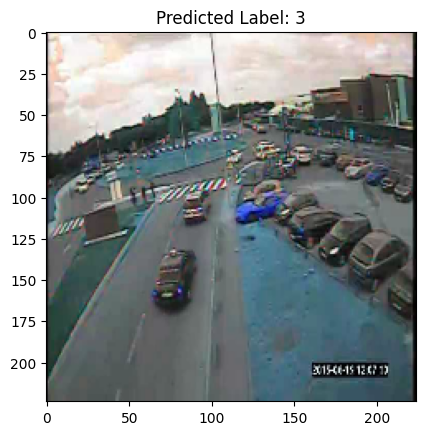

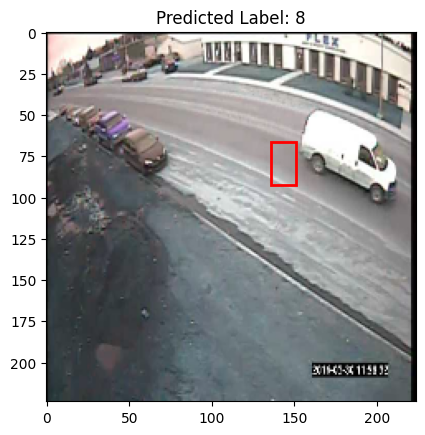

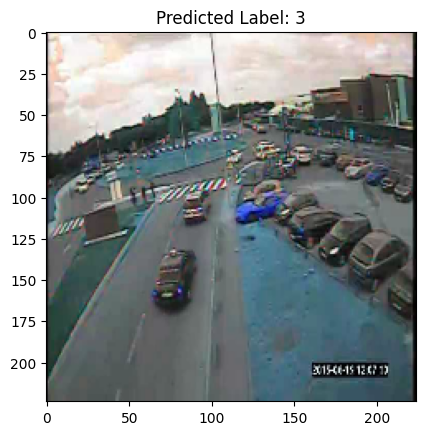

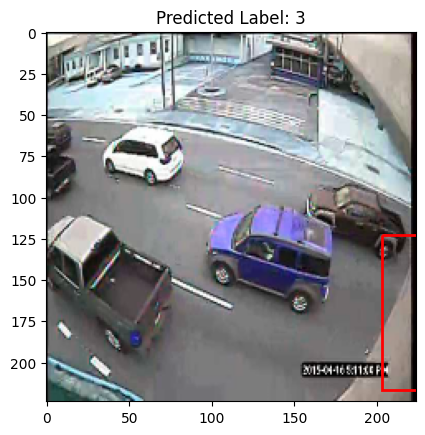

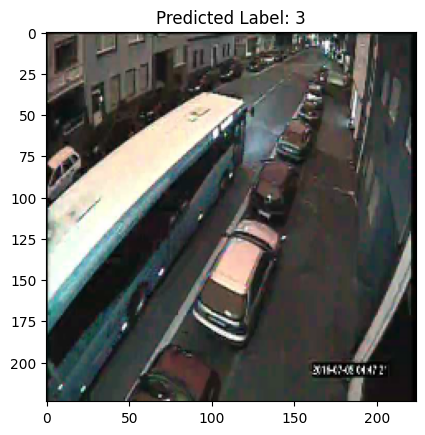

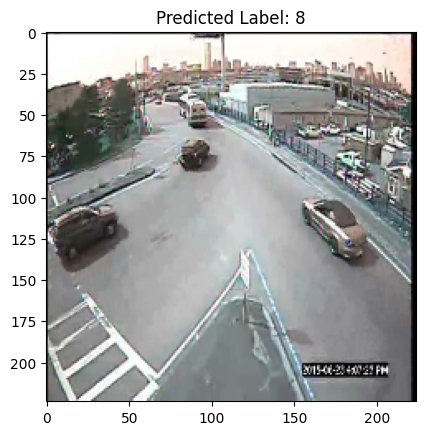

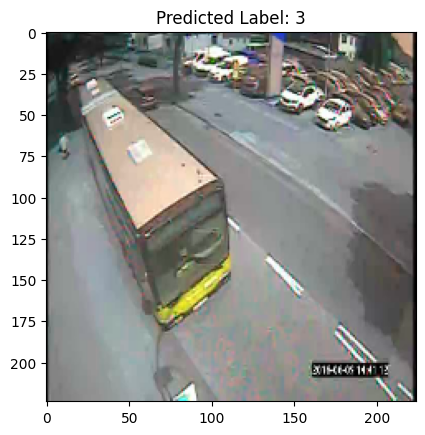

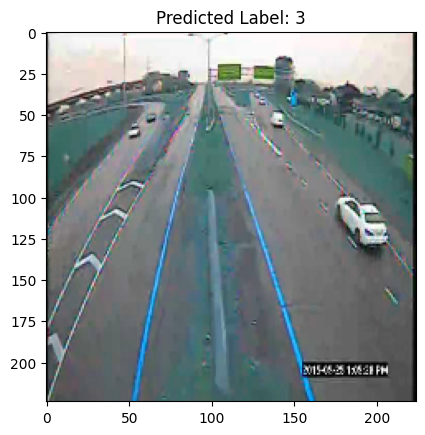

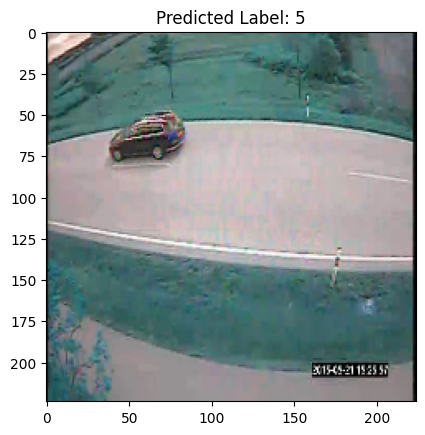

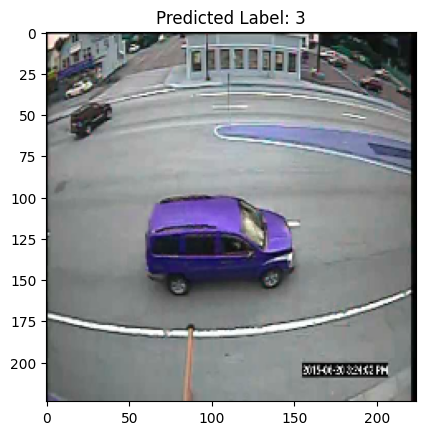

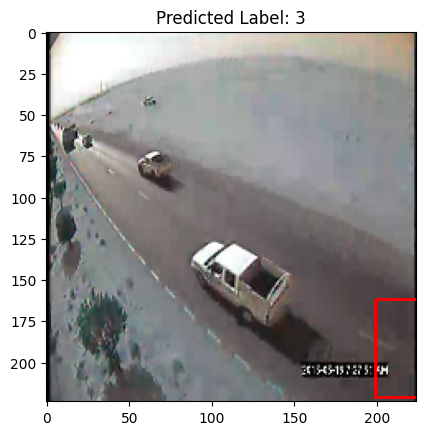

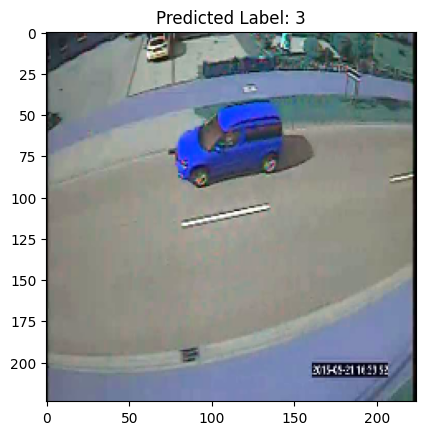

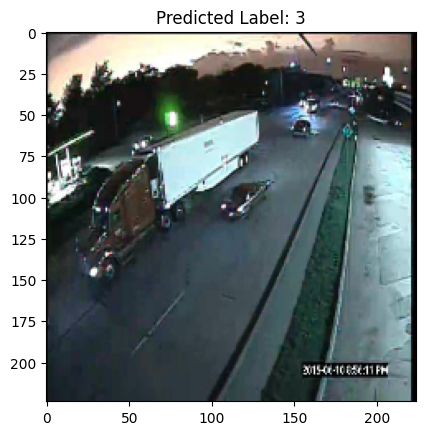

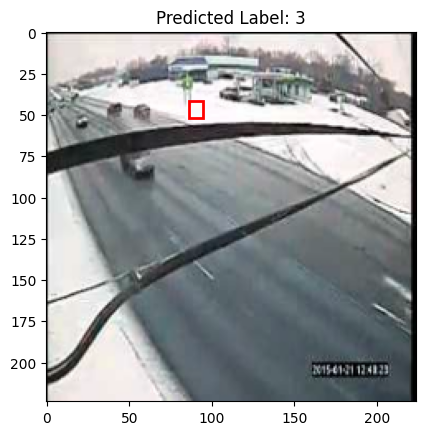

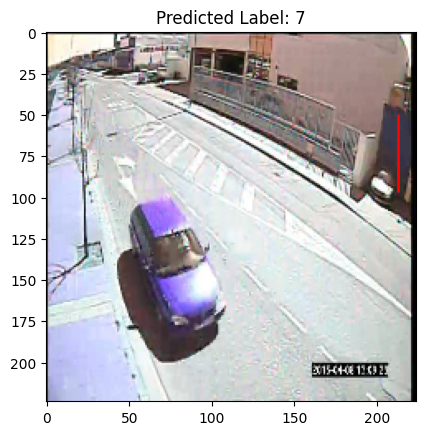

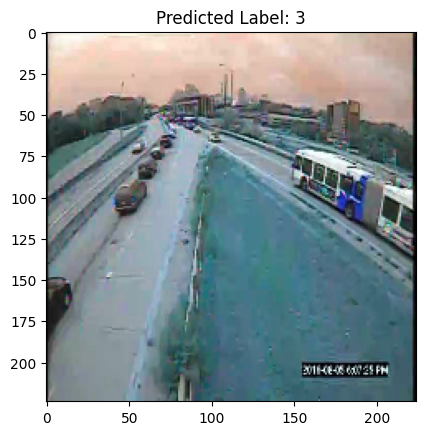

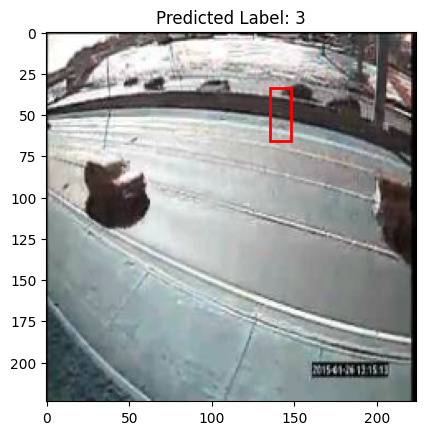

In [44]:
import matplotlib.pyplot as plt
# Choose a few sample images for inference
sample_images = X_test[:20]  # Adjust the number of sample images as needed
# Perform inference on the sample images
predictions = model.predict(sample_images)
# Extract the predicted bounding box coordinates
predicted_bounding_boxes = predictions[1]
# add labels also in for loop
# Extract the predicted labels
predicted_labels = [index_to_label[label] for label in np.argmax(predictions[0], axis=1)]
# Visualize the sample images with predicted bounding boxes
for i in range(len(sample_images)):
    plt.figure()
    plt.imshow(sample_images[i])
    # add labels also
    plt.title(f"Predicted Label: {predicted_labels[i]}")
    plt.gca().add_patch(plt.Rectangle((predicted_bounding_boxes[i][0], predicted_bounding_boxes[i][1]),
                                     predicted_bounding_boxes[i][2] - predicted_bounding_boxes[i][0],
                                     predicted_bounding_boxes[i][3] - predicted_bounding_boxes[i][1],
                                     fill=False, edgecolor='r', linewidth=2))
    plt.show()